In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
df = pd.read_csv('gemini.csv')

In [12]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [9]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-04-20 18:07:58,622] A new study created in memory with name: no-name-cf9747f2-4b85-4a60-83e2-c44c2c23cfca
[I 2026-04-20 18:07:58,654] Trial 0 finished with value: 0.5222222222222223 and parameters: {'max_depth': 7, 'min_samples_leaf': 19, 'min_samples_split': 4, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5222222222222223.
[I 2026-04-20 18:07:58,671] Trial 1 finished with value: 0.875 and parameters: {'max_depth': 7, 'min_samples_leaf': 15, 'min_samples_split': 12, 'criterion': 'entropy'}. Best is trial 1 with value: 0.875.
[I 2026-04-20 18:07:58,687] Trial 2 finished with value: 0.5805555555555555 and parameters: {'max_depth': 10, 'min_samples_leaf': 16, 'min_samples_split': 4, 'criterion': 'gini'}. Best is trial 1 with value: 0.875.
[I 2026-04-20 18:07:58,698] Trial 3 finished with value: 0.9277777777777778 and parameters: {'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 3, 'criterion': 'entropy'}. Best is trial 3 with value: 0.9277777777777778.
[I 202

Best params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 12, 'criterion': 'entropy'}
Best score: 0.95


In [13]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth= 3)
model = classifier.fit(X_train, y_train)
# classifier = DecisionTreeClassifier(**study.best_params, random_state=1)
# model = classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

Accuracy:0.875
Precision:1.000
Recall:  0.769
F1-score: 0.870

Confusion Matrix:
 [[11  0]
 [ 3 10]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      1.00      0.88        11
         1.0       1.00      0.77      0.87        13

    accuracy                           0.88        24
   macro avg       0.89      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24

F1-результаты по фолдам: [1.         0.8        0.66666667 1.         0.8       ]
Средний F1: 0.85


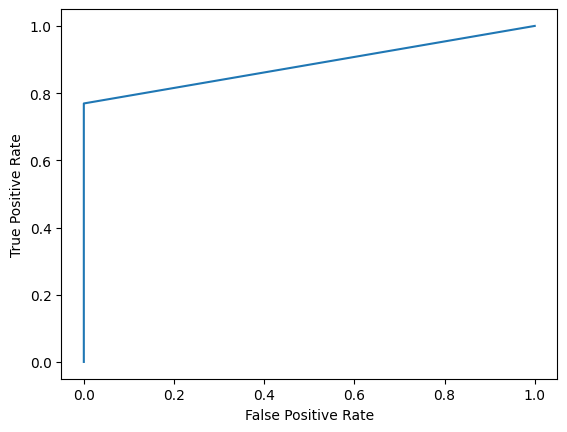

In [14]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 87.50%


In [16]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.875
Precision:1.000
Recall:  0.769
F1-score: 0.870
ROC-AUC:1.000

Confusion Matrix:
 [[11  0]
 [ 3 10]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      1.00      0.88        11
         1.0       1.00      0.77      0.87        13

    accuracy                           0.88        24
   macro avg       0.89      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24



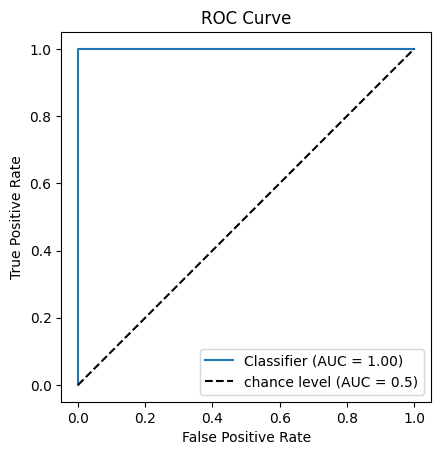

In [17]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

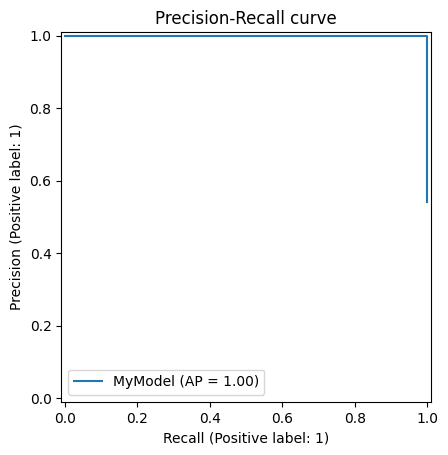

In [18]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

снизу оптимизаторы

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


KeyboardInterrupt: 

In [10]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.tree import DecisionTreeClassifier

opt = BayesSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    search_spaces={
        'max_depth': Integer(1, 20),
        'min_samples_leaf': Integer(1, 20),
        'min_samples_split': Integer(2, 20),
        'criterion': Categorical(["entropy", "gini"])
    },
    n_iter=32,
    cv=5,
    random_state=1,
    verbose=1
)

opt.fit(X_train, y_train)

print("best accuracy:", opt.best_score_)
print(opt.best_estimator_)

ModuleNotFoundError: No module named 'yaml'

In [11]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier

param_dist = {
    'max_depth': randint(1, 20),
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'criterion': ["gini", "entropy"]
}

halving = HalvingRandomSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=param_dist,
    factor=2,
    random_state=1,
    verbose=1
)

halving.fit(X_train, y_train)

print("best accuracy:", halving.best_score_)
print(halving.best_estimator_)

n_iterations: 1
n_required_iterations: 1
n_possible_iterations: 1
min_resources_: 20
max_resources_: 34
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 1
n_resources: 20
Fitting 5 folds for each of 1 candidates, totalling 5 fits
best accuracy: 0.5833333333333333
DecisionTreeClassifier(criterion='entropy', max_depth=12, min_samples_leaf=13,
                       min_samples_split=10, random_state=1)


In [42]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

c:\Users\e.i.chapaev\.conda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-13 18:23:07,459] A new study created in memory with name: no-name-d988a037-255f-4a8f-848e-55dfce065db7
[I 2026-04-13 18:23:07,476] Trial 0 finished with value: 0.9527777777777778 and parameters: {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 4, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9527777777777778.
[I 2026-04-13 18:23:07,493] Trial 1 finished with value: 0.5722222222222222 and parameters: {'max_depth': 13, 'min_samples_leaf': 20, 'min_samples_split': 18, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9527777777777778.
[I 2026-04-13 18:23:07,512] Trial 2 finished with value: 0.9527777777777778 and parameters: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'crit

Best params: {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 4, 'criterion': 'entropy'}
Best score: 0.9527777777777778
